# Assignment 4 – 100% Renewable Electricity System
## Data Science for Energy System Modelling

This notebook is the master workflow for the assignment.





## 0. Environment Setup

**Goal:** Complete this stage before moving to the next.

In [4]:
# Imports
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import atlite
from atlite.gis import ExclusionContainer, shape_availability
from rasterio.plot import show
from rasterio.features import geometry_mask
from atlite.gis import ExclusionContainer
import unicodedata
import xarray as xr
import requests
from urllib.request import urlretrieve
from os.path import basename
import matplotlib.dates as mdates
import pypsa
from shapely.geometry import Point

In [5]:
prt_url = "https://raw.githubusercontent.com/mpatel-7734/Portugal-Assignment/main/country_shapes.geojson"
wdpa_url = "https://raw.githubusercontent.com/mpatel-7734/Portugal-Assignment/main/WDPA_Oct2022_Public_shp-PRT.tif"
airports_url = "https://raw.githubusercontent.com/mpatel-7734/Portugal-Assignment/main/ne_10m_airports.gpkg"
roads_url = "https://raw.githubusercontent.com/mpatel-7734/Portugal-Assignment/main/ne_10m_roads.gpkg"
gebco_url = "https://tubcloud.tu-berlin.de/s/XoDpBcweJHmYKgF/download/GEBCO_2014_2D-PT.nc"
lc_url = "https://raw.githubusercontent.com/mpatel-7734/Portugal-Assignment/main/PROBAV_LC100_global_v3.0.1_2019-nrt_Discrete-Classification-map_EPSG-4326-PT.tif"
prt_region_url = "https://raw.githubusercontent.com/mpatel-7734/Portugal-Assignment/main/gadm_410-levels-ADM_1-PRT.gpkg"
load_url = "https://raw.githubusercontent.com/mpatel-7734/Portugal-Assignment/main/load.csv"
gebco = "GEBCO_2014_2D-PT.nc"
eez_url = "https://tubcloud.tu-berlin.de/s/ZTYbJjm8tq4ijpt/download/eez_v11.gpkg"
gppd_url = "https://raw.githubusercontent.com/mpatel-7734/Portugal-Assignment/main/global_power_plant_database.csv"

In [6]:
# import requests
# from urllib.request import urlretrieve
# from os.path import basename

# url = (
#     "https://tubcloud.tu-berlin.de/s/2oogpgBfM5n4ssZ/download/PORTUGAL-2013-01-era5.nc"
# )
# urlretrieve(url, basename(url));

## 1. Country Selection


<Axes: >

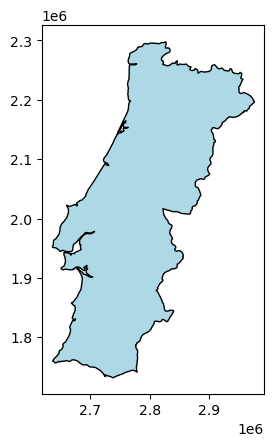

In [7]:
country = gpd.read_file(prt_url).to_crs(epsg=3035)
portugal = country[country["name"] == "PT"]
prt = portugal.to_crs(epsg = 3035)['geometry']
portugal.plot(color = 'lightblue', edgecolor = 'black')

## 2. Country shape and model regions

The assignment requires **at least 5 regions**. We load the 20 GADM level-1
districts of Portugal and aggregate them into the **5 mainland NUTS-2 regions**
(Norte, Centro, Lisboa, Alentejo, Algarve). We drop the **Azores** and
**Madeira** islands — they are overseas territories, which the task sheet
allows us to disregard.

Why aggregate instead of keeping 20 districts? Fewer regions keep the
optimisation problem small enough to solve quickly, and NUTS-2 regions are
official statistical units, so population data for the load distribution is
easy to find later.

**Steps in the cell below:**
1. define which district belongs to which region (a simple dictionary),
2. normalise the district names (GADM uses accents like *Setúbal*, our
   dictionary keys don't),
3. drop the islands, label every district with its region,
4. `dissolve` — merge all districts with the same label into one region shape.

In [8]:
prt_gadm = gpd.read_file(prt_region_url).to_crs(epsg=3035)
# 1) define which district belongs to which of the 5 model regions
region_map = {
    # North
    "braga": "North",
    "braganca": "North",
    "porto": "North",
    "viana do castelo": "North",
    "vila real": "North",
    # Center
    "aveiro": "Center",
    "castelo branco": "Center",
    "coimbra": "Center",
    "guarda": "Center",
    "leiria": "Center",
    
    "viseu": "Center",
    # Lisbon
    "lisboa": "Lisbon",
    "setubal": "Lisbon",
    # Alentejo
    "beja": "Alentejo",
    "evora": "Alentejo",
    "santarem": "Alentejo",
    "portalegre": "Alentejo",
    # Algarve
    "faro": "Algarve",
} 
ISLANDS = {"azores", "madeira"}
# 2) normalise district names: strip accents (e.g. "Setúbal" -> "setubal")
def strip_accents(text):
    text = unicodedata.normalize("NFKD", str(text))
    return "".join(c for c in text if not unicodedata.combining(c)).lower()
prt_gadm["key"] = prt_gadm["NAME_1"].apply(strip_accents)

# 3) drop the islands and label every district with its region
main_land = prt_gadm[~prt_gadm["key"].isin(ISLANDS)].copy()
main_land["region"] = main_land["key"].map(region_map)

# 4) dissolve: merge districts with the same label into one region shape
regions = main_land.dissolve(by="region")[["geometry"]]
regions


,geometry
region,
Alentejo,"MULTIPOLYGON (((2726797.123 1774795.195, 27267..."
Algarve,"MULTIPOLYGON (((2642809.829 1757654.459, 26428..."
Center,"MULTIPOLYGON (((2652556.415 2030042.405, 26525..."
Lisbon,"MULTIPOLYGON (((2637740.323 1950901.258, 26377..."
North,"MULTIPOLYGON (((2764029.832 2200543.414, 27640..."


### Map of the model regions

A quick visual check that the aggregation worked — we plot the five regions,
each in its own colour:

1. create the figure (taller than wide, since Portugal is),
2. plot the regions, coloured by region name, with black borders and a legend,
3. label the axes (coordinates are in degrees, since GADM data comes in
   the geographic CRS EPSG:3035) and add a title.

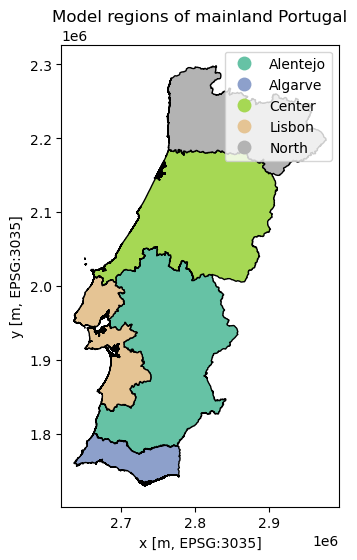

In [9]:
fig, ax = plt.subplots(figsize=(5, 6))

# 2) plot the regions, coloured by region name, with a legend
regions.reset_index().plot(ax=ax, column="region", cmap="Set2",edgecolor="black", legend=True)

# 3) axis labels with units and a title
ax.set_title("Model regions of mainland Portugal")
ax.set_xlabel("x [m, EPSG:3035]")   # label under the horizontal axis
ax.set_ylabel("y [m, EPSG:3035]")   # label beside the vertical axis
plt.show()

### Region areas

To compute areas correctly we must use an **equal-area projection** — in the
default geographic coordinates (degrees of latitude/longitude), area
calculations would be distorted. For Europe the standard choice is
**EPSG:3035**, which measures in metres:

1. reproject the regions to EPSG:3035,
2. compute the area and convert from m² to km².

In [10]:
# 1) equal-area projection for Europe (units: metres)
AREA_CRS = "EPSG:3035"

# 2) area per region in km^2 (divide m^2 by 1e6)
regions["area_km2"] = regions.to_crs(AREA_CRS).area / 1e6
regions["area_km2"].round(0)

region
Alentejo    30456.0
Algarve      4966.0
Center      27397.0
Lisbon       7782.0
North       18156.0
Name: area_km2, dtype: float64

## 3. Total Area of Portugal

In [11]:
prt_area_m2 = prt.area.iloc[0]
print('total area', prt_area_m2/1000000) #in km2

total area 87952.07084479544


## 4. Electricity demand (load)

The GEGIS dataset provides an **hourly national** demand time series for 2013
(in MW). Our model is regional, so we are spliting the national load across the
5 regions. As the task sheet suggests, we use each region's **share of the
national population** as the distribution key — people are a good proxy for
where electricity is consumed.

Population per region from the 2021 census (rounded).

In [12]:
# hourly national electricity demand of Portugal in 2013 [MW]
national_load = pd.read_csv(load_url, index_col=0, parse_dates=True)["PT"]
national_load.describe().round(0)

count    8760.0
mean     6377.0
std       722.0
min      5033.0
25%      5682.0
50%      6449.0
75%      6998.0
max      8057.0
Name: PT, dtype: float64

## 5. Land Eligibility Analysis (onshore wind & solar)

Not all land can host wind turbines or solar parks. Using `atlite`'s
`ExclusionContainer` (as in Assignment 2) we exclude unsuitable land, based on
the criteria from the task sheet:

| Criterion | Rule |
|---|---|
| Land cover | keep **only** suitable classes (shrubs, herbaceous vegetation, cropland, bare/sparse) |
| Built-up areas | exclude a **1 km** buffer around settlements |
| Protected areas | exclude (WDPA dataset) |
| Elevation | exclude land above **2000 m** (GEBCO dataset) |
| Airports | exclude within **10 km** |
| Major roads | exclude within **300 m** |

The land-cover dataset is the Copernicus **PROBA-V** global map at 100 m
resolution (class codes documented at https://zenodo.org/record/4723921).
Our choice of suitable classes is a judgement call the task sheet allows:
we keep open vegetation and agricultural land, and exclude forests, wetlands
and water.

In [13]:
# 3) load the global files only within a box around Portugal (+1 degree margin)
box = tuple(regions.to_crs(4326).total_bounds + np.array([-1, -1, 1, 1]))
airports = gpd.read_file(airports_url, bbox=box)
roads    = gpd.read_file(roads_url, bbox=box)
print(f"{len(airports)} airports and {len(roads)} road segments near Portugal")

4 airports and 161 road segments near Portugal


### Building the exclusion container

We now translate each criterion from the table into one rule in an
`ExclusionContainer` (working grid: EPSG:3035 at 100 m resolution):

1. **land cover** — keep *only* the suitable classes; `invert=True` turns the
   rule from an exclude-list into an include-list,
2. **built-up areas** — exclude class 50 plus a 1000 m buffer,
3. **protected areas** — exclude WDPA cells with value 1,
4. **elevation** — exclude cells above 2000 m (a condition instead of codes),
5. **airports & roads** — exclude 10 000 m and 300 m buffers around the
   vector geometries.

All buffers are in **metres**. Each dataset comes in its own projection, so we
pass its `crs` and let `atlite` reproject everything onto the common grid.

In [14]:
# gebco = r"C:\Users\mayan\OneDrive\Documents\Portugal\GEBCO_2014_2D-PT.nc"
gebco = "GEBCO_2014_2D-PT.nc"
url = (
    "https://tubcloud.tu-berlin.de/s/PgTtiARofnwjXYA/download/" + gebco
)
urlretrieve(url, basename(url));


In [15]:
# PROBA-V land-cover classes we consider SUITABLE for wind/solar:
#   20 = shrubs, 30 = herbaceous vegetation, 40 = cropland, 60 = bare/sparse
suitable_land = [20, 30, 40, 60]
built_up = 50  # urban / built-up class

def onshore_excluder():
    exc = ExclusionContainer(crs=3035, res=100)   # 100 m resolution grid
    # 1) keep ONLY suitable land cover
    exc.add_raster(lc_url, codes=suitable_land, invert=True, crs=4326,nodata=48)
    # 2) exclude a 1 km buffer around built-up areas
    exc.add_raster(lc_url, codes=[built_up], buffer=1000, crs=4326,nodata=48)
    # 3) exclude protected areas (1 = protected)
    exc.add_raster(wdpa_url, codes=[1], crs="ESRI:54009")
    # 4) exclude land above 2000 m elevation
    exc.add_raster(gebco, codes=lambda x: x > 2000, crs=4326)
    # 5) exclude 10 km around airports and 300 m around major roads
    exc.add_geometry(airports.geometry, buffer=10000)
    exc.add_geometry(roads.geometry, buffer=300)
    return exc

excluder = onshore_excluder()
print(regions.crs)
print(regions.total_bounds)

EPSG:3035
[2635889.29460472 1729651.006614   2977223.82854547 2298232.38847388]


### Visual check: eligible land of all regions

Before using the excluder everywhere, we check it visually on all regions:

1. compute the availability mask for Alentejo with `shape_availability()`
   (returns a True/False grid at 100 m resolution),
2. plot the eligible cells in green over the region outline,
3. compute the eligible share: number of eligible cells × cell area,
   divided by the region's total area.

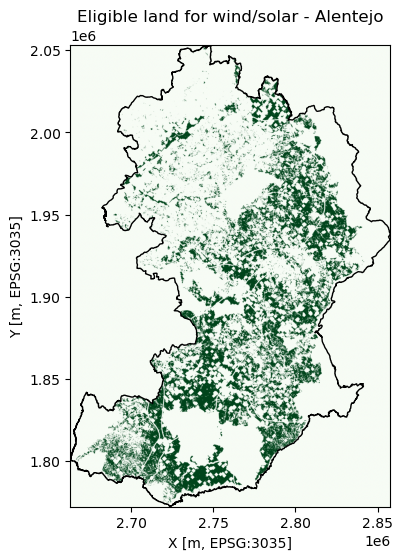

Alentejo: 24.9% of the land area is eligible


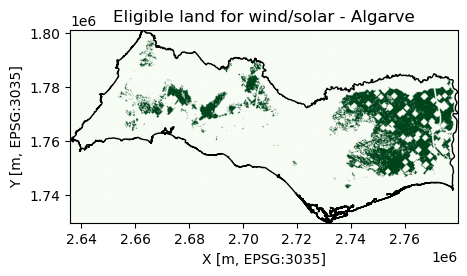

Algarve: 19.5% of the land area is eligible


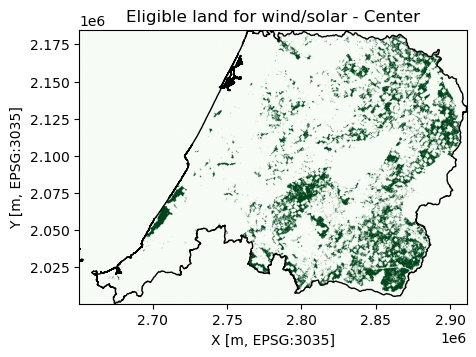

Center: 16.5% of the land area is eligible


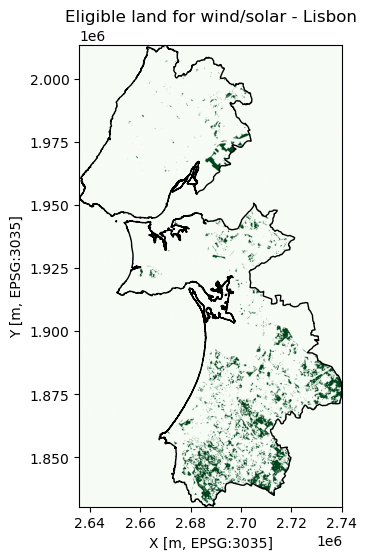

Lisbon: 8.4% of the land area is eligible


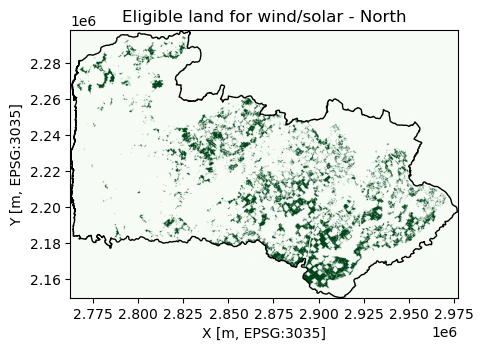

North: 12.7% of the land area is eligible


In [16]:
for region in regions.index:
    # Region geometry
    shape = regions.to_crs(3035).loc[[region]].geometry
    # Availability mask
    available, transform = shape_availability(shape, excluder)
    # Plot
    fig, ax = plt.subplots(figsize=(5, 6))
    shape.plot(ax=ax, color="none", edgecolor="black")
    show(available,transform=transform,cmap="Greens",ax=ax)
    ax.set_title(f"Eligible land for wind/solar - {region}")
    ax.set_xlabel("X [m, EPSG:3035]")
    ax.set_ylabel("Y [m, EPSG:3035]")
    plt.show()
    # Eligible share
    eligible_share = (available.sum() * excluder.res**2/ shape.area.iloc[0] * 100)
    print(f"{region}: {eligible_share:.1f}% of the land area is eligible")

Alentejo: 24.9% of the land area is eligible
Algarve: 19.5% of the land area is eligible
Center: 16.5% of the land area is eligible
Lisbon: 8.4% of the land area is eligible
North: 12.7% of the land area is eligible


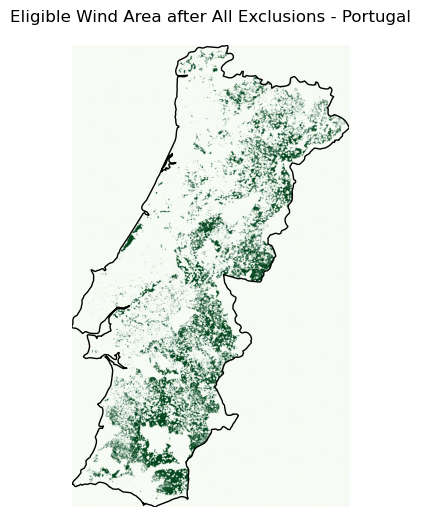

In [17]:
for region in regions.index:
    # Region geometry
    shape = regions.to_crs(3035).loc[[region]].geometry
    # Availability mask
    available, transform = shape_availability(shape, excluder)
    # Eligible share
    eligible_share = (available.sum() * excluder.res**2/ shape.area.iloc[0] * 100)
    print(f"{region}: {eligible_share:.1f}% of the land area is eligible")
    
# Portugal geometry
shape = portugal.to_crs(3035).geometry
available, transform = shape_availability(shape, excluder)   # or excluder for wind
# Plot
fig, ax = plt.subplots(figsize=(4, 6))
show(available,transform=transform,cmap="Greens",ax=ax)
shape.boundary.plot(ax=ax,edgecolor="black",linewidth=1)
ax.set_title("Eligible Wind Area after All Exclusions - Portugal")
ax.set_axis_off()

plt.show()

## Wind eligible area in km2

In [18]:
# Calculate eligible wind area for each region

wind_area = []
for region in regions.index:
    # Region geometry
    shape = regions.to_crs(3035).loc[[region]].geometry
    # Availability mask for wind
    available, transform = shape_availability(shape, excluder)
    # Eligible share (%)
    eligible_pct = (
        available.sum() * excluder.res**2
        / shape.area.iloc[0]
        * 100
    )
    # Total area of the region (km²)
    total_area_km2 = regions.loc[region, "area_km2"]

    # Eligible area (km²)
    eligible_area_km2 = total_area_km2 * eligible_pct / 100

    wind_area.append({
        "region": region,
        "area_km2": total_area_km2,
        "eligible_pct": eligible_pct,
        "eligible_area_km2": eligible_area_km2
    })

# Convert to DataFrame
wind_regions = pd.DataFrame(wind_area)

# Display results
print(wind_regions)

     region      area_km2  eligible_pct  eligible_area_km2
0  Alentejo  30456.291100     24.873350            7575.50
1   Algarve   4965.662778     19.465075             966.57
2    Center  27396.664669     16.546613            4533.22
3    Lisbon   7782.120702      8.442429             657.00
4     North  18155.599236     12.713709            2308.25


### 6. Exclusive Economic Zone (EEZ)

Portugal has an Atlantic coast, so the task sheet asks us to also extract the
**EEZ** — the sea area belonging to the country. We need it later for the
offshore wind analysis:

1. keep only the Portuguese EEZ (filter by territory name),
2. reproject to the equal-area CRS for later area calculations.

In [19]:
eez = gpd.read_file(eez_url).to_crs(epsg=3035)
# 2) keep only Portugal's EEZ, 3) reproject to the equal-area CRS
portugal_eez = eez[eez["TERRITORY1"] == "Portugal"].to_crs(AREA_CRS)
portugal_eez[["GEONAME", "TERRITORY1"]]

,GEONAME,TERRITORY1
104,Portuguese Exclusive Economic Zone,Portugal


## Off Shorewind

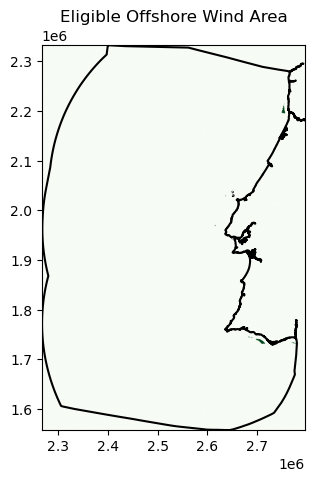

Eligible offshore area = 163.50 km²


In [20]:


# Offshore exclusion container
offshore_exc = ExclusionContainer(crs=3035, res=500)

# 1. Water depth must be <= 50 m
# GEBCO elevation:
# positive = land
# negative = sea
# keep only -50 m ... 0 m

offshore_exc.add_raster(
    gebco,
    codes=lambda x: (x < -50) | (x > 0),
    crs=4326
)

# 2. Exclude marine protected areas
offshore_exc.add_raster(
    wdpa_url,
    codes=[1],
    crs="ESRI:54009"
)

# 3. Exclude everything within 10 km of the coast
shore_buffer = portugal.to_crs(3035).buffer(10000)

offshore_exc.add_geometry(
    shore_buffer,
    invert=False
)

# --------------------------------------------------
# Availability inside Portugal EEZ
# --------------------------------------------------

shape = portugal_eez.geometry

available, transform = shape_availability(
    shape,
    offshore_exc
)

# Plot
fig, ax = plt.subplots(figsize=(4,5))

portugal_eez.boundary.plot(ax=ax, color="black")

show(
    available,
    transform=transform,
    cmap="Greens",
    ax=ax
)

ax.set_title("Eligible Offshore Wind Area")

plt.show()

# Eligible area

offshore_area_km2 = (
    available.sum()
    * offshore_exc.res**2
    / 1e6
)
print(f"Eligible offshore area = {offshore_area_km2:.2f} km²")


<Axes: >

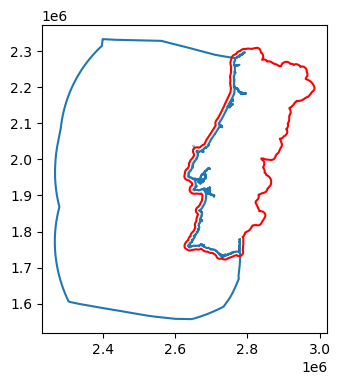

In [21]:
fig, ax = plt.subplots(figsize=(4,4))

portugal_eez.boundary.plot(ax=ax)
shore_buffer.boundary.plot(ax=ax, color="red")


## Solar

In [22]:
# Suitable CORINE land cover classes
# 20 = shrubs
# 30 = herbaceous vegetation
# 40 = cropland
# 60 = bare/sparse

suitable_land = [20, 30, 40, 60]

def solar_excluder():

    exc = ExclusionContainer(crs=3035, res=100)

    # Keep only suitable land-cover classes
    exc.add_raster(
        lc_url,
        codes=suitable_land,
        invert=True,
        crs=4326
    )

    # Exclude protected areas
    exc.add_raster(
        wdpa_url,
        codes=[1],
        crs="ESRI:54009"
    )

    return exc

solar_exc = solar_excluder()

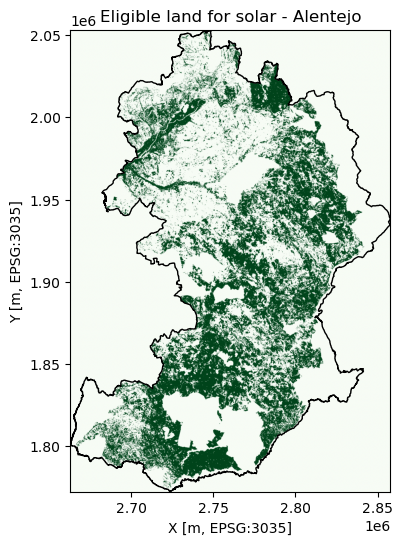

Alentejo: 36.8% of the land area is eligible


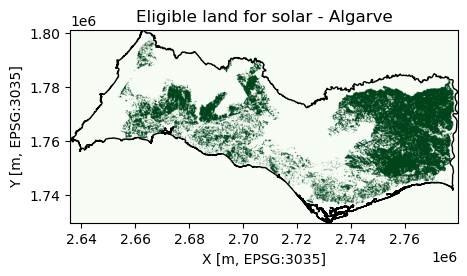

Algarve: 34.2% of the land area is eligible


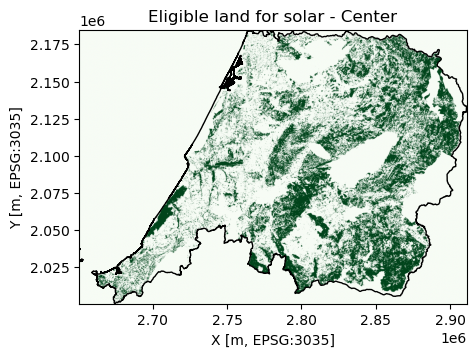

Center: 32.2% of the land area is eligible


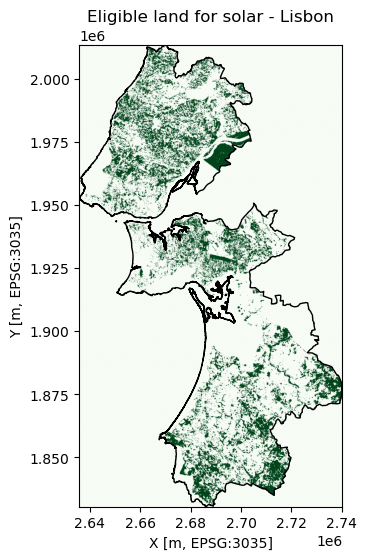

Lisbon: 25.7% of the land area is eligible


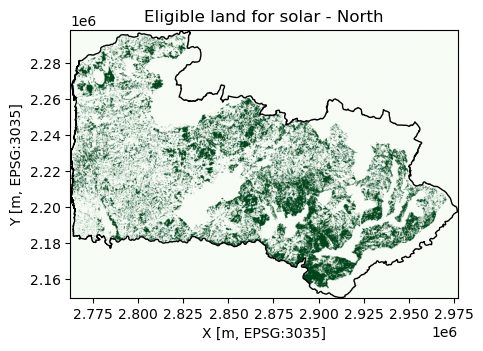

North: 26.5% of the land area is eligible


In [23]:
import warnings
warnings.filterwarnings("ignore")
for region in regions.index:
    # Region geometry
    shape = regions.to_crs(3035).loc[[region]].geometry
    # Availability mask
    pv_available, transforms = shape_availability(shape, solar_exc)
    # Plot
    fig, ax = plt.subplots(figsize=(5, 6))
    shape.plot(ax=ax, color="none", edgecolor="black")
    show(pv_available, transform=transforms, cmap="Greens", ax=ax)
    ax.set_title(f"Eligible land for solar - {region}")
    ax.set_xlabel("X [m, EPSG:3035]")
    ax.set_ylabel("Y [m, EPSG:3035]")
    plt.show()
    # Eligible share
    eligible_share = (pv_available.sum() * solar_exc.res**2 / shape.area.iloc[0] * 100)
    print(f"{region}: {eligible_share:.1f}% of the land area is eligible")



Alentejo: 36.76% of the land area is eligible
Algarve: 34.17% of the land area is eligible
Center: 32.15% of the land area is eligible
Lisbon: 25.71% of the land area is eligible
North: 26.54% of the land area is eligible


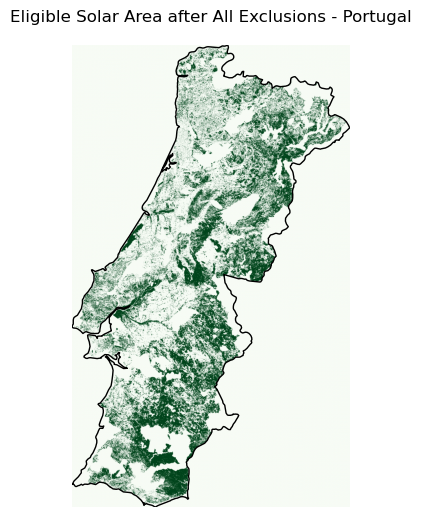

In [24]:
# Eligible share for each region

for region in regions.index:

    # Region geometry
    shape = regions.to_crs(3035).loc[[region]].geometry

    # Availability mask for this region
    pv_available, transform = shape_availability(shape, solar_exc)

    # Eligible share (%)
    eligible_share = (
        pv_available.sum() * solar_exc.res**2
        / shape.area.iloc[0]
        * 100
    )

    # Print result
    print(f"{region}: {eligible_share:.2f}% of the land area is eligible")


# Portugal geometry
shape = portugal.to_crs(3035).geometry
available, transform = shape_availability(shape, solar_exc)   # or excluder for wind
# Plot
fig, ax = plt.subplots(figsize=(4, 6))
show(available,transform=transform,cmap="Greens",ax=ax)
shape.boundary.plot(ax=ax,edgecolor="black",linewidth=1)
ax.set_title("Eligible Solar Area after All Exclusions - Portugal")
ax.set_axis_off()
plt.show()

## Solar elegible area in km2

In [25]:
# Create an empty list
solar_area = []

for region in regions.index:

    # Region geometry
    shape = regions.to_crs(3035).loc[[region]].geometry

    # Availability mask
    pv_available, transform = shape_availability(shape, solar_exc)

    # Eligible percentage
    eligible_pct = (
        pv_available.sum() * solar_exc.res**2
        / shape.area.iloc[0]
        * 100
    )

    # Region area (km²)
    total_area_km2 = regions.loc[region, "area_km2"]

    # Eligible area (km²)
    eligible_area_km2 = total_area_km2 * eligible_pct / 100

    solar_area.append({
        "region": region,
        "area_km2": total_area_km2,
        "eligible_pct": eligible_pct,
        "eligible_area_km2": eligible_area_km2
    })

# Convert to DataFrame
solar_regions = pd.DataFrame(solar_area)

# Display results
print(solar_regions)

     region      area_km2  eligible_pct  eligible_area_km2
0  Alentejo  30456.291100     36.759236           11195.50
1   Algarve   4965.662778     34.165228            1696.53
2    Center  27396.664669     32.151249            8808.37
3    Lisbon   7782.120702     25.706232            2000.49
4     North  18155.599236     26.538865            4818.29


## 7. Total elegible area

In [26]:
#total eligible area for onshore, offshore and solar
#1. Total Onshore Wind Eligible Area (km²)
# Availability
wind_available, _ = shape_availability(prt, excluder)

# Eligible area (km²)
wind_area = wind_available.sum() * excluder.res**2 / 1e6

#2. Total Solar Eligible Area (km²)
# Availability
solar_available, _ = shape_availability(prt, solar_exc)

# Eligible area (km²)
solar_area = solar_available.sum() * solar_exc.res**2 / 1e6


print(f"Onshore Wind Eligible Area : {wind_area:.2f} km²")
print(f"Solar Eligible Area        : {solar_area:.2f} km²")
print(f"Eligible offshore area     : {eligible_area_km2:.2f} km²")

print(f"Total Eligible Area        : {wind_area + solar_area + eligible_area_km2:.2f} km²")

Onshore Wind Eligible Area : 16051.13 km²
Solar Eligible Area        : 28571.17 km²
Eligible offshore area     : 4818.29 km²
Total Eligible Area        : 49440.59 km²


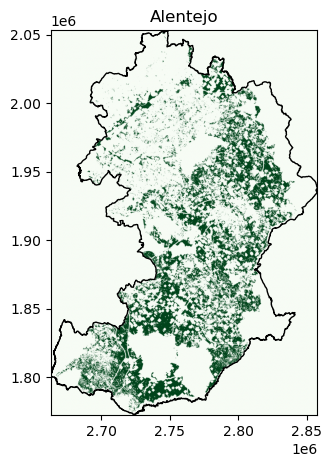

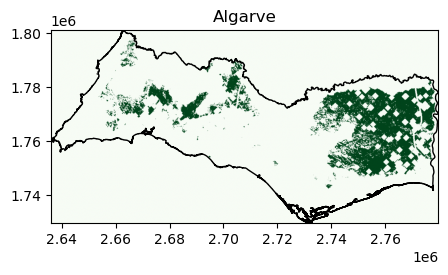

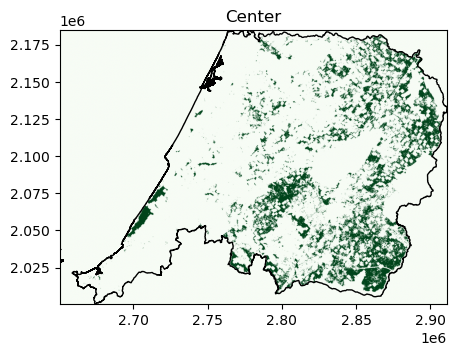

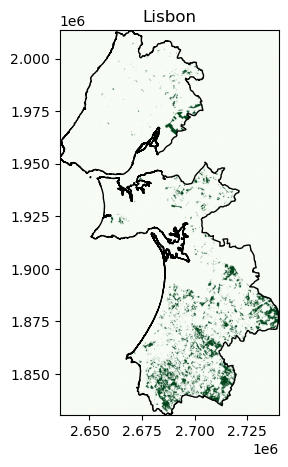

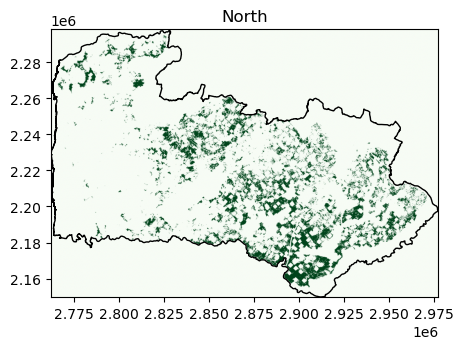

In [27]:
for region in regions.index:

    shape = regions.to_crs(3035).loc[[region]].geometry

    available, transform = shape_availability(shape, excluder)

    fig, ax = plt.subplots(figsize=(5,5))

    shape.plot(ax=ax, facecolor="none", edgecolor="black")

    show(
        available,
        transform=transform,
        cmap="Greens",
        ax=ax
    )

    ax.set_title(region)
    plt.show()

## 8. Capacity factor


## ERA5

<Axes: >

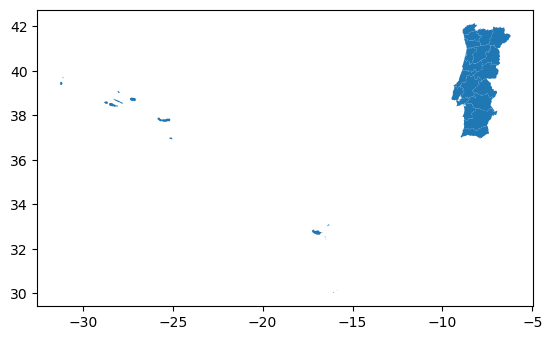

In [28]:
region = gpd.read_file(prt_region_url)
region.plot()

In [29]:

#Extract bounds
'''minx, miny, maxx, maxy = region.total_bounds


buffer = 0.25

# 6. Build and prepare cutout (forcing overwrite to clear corrupted partial downloads)
cutout = atlite.Cutout(
    path="era5-2019-PT.nc",
    module="era5",
    x=slice(minx - buffer, maxx + buffer),
    y=slice(miny - buffer, maxy + buffer),
    time="2019",
)
cutout.prepare()'''

'minx, miny, maxx, maxy = region.total_bounds\n\n\nbuffer = 0.25\n\n# 6. Build and prepare cutout (forcing overwrite to clear corrupted partial downloads)\ncutout = atlite.Cutout(\n    path="era5-2019-PT.nc",\n    module="era5",\n    x=slice(minx - buffer, maxx + buffer),\n    y=slice(miny - buffer, maxy + buffer),\n    time="2019",\n)\ncutout.prepare()'

In [30]:
fn = "era5-2019-PT.nc"
url = "https://tubcloud.tu-berlin.de/s/fjFi8BC9b9dqfAZ/download/" + fn
urlretrieve(url, fn)
cutout = atlite.Cutout(fn)
prt_regions = regions.to_crs(4326)
cutout.data

<xarray.Dataset> Size: 3GB
Dimensions:               (y: 50, x: 103, time: 8760)
Coordinates:
  * y                     (y) float64 400B 30.0 30.25 30.5 ... 41.75 42.0 42.25
    lat                   (y) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * x                     (x) float64 824B -31.5 -31.25 -31.0 ... -6.25 -6.0
    lon                   (x) float64 824B dask.array<chunksize=(103,), meta=np.ndarray>
  * time                  (time) datetime64[ns] 70kB 2019-01-01 ... 2019-12-3...
Data variables: (12/15)
    height                (y, x) float32 21kB dask.array<chunksize=(50, 103), meta=np.ndarray>
    wnd100m               (time, y, x) float32 180MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
    wnd_shear_exp         (time, y, x) float64 361MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
    wnd_azimuth           (time, y, x) float32 180MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
    roughness             (time, y, x) float32 180MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
    influx_toa            (time, y, x) float32 180MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
    ...                    ...
    solar_altitude        (time, y, x) float64 361MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
    solar_azimuth         (time, y, x) float64 361MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
    temperature           (time, y, x) float32 180MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
    soil temperature      (time, y, x) float32 180MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
    dewpoint temperature  (time, y, x) float32 180MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
    runoff                (time, y, x) float32 180MB dask.array<chunksize=(100, 50, 103), meta=np.ndarray>
Attributes:
    module:                  era5
    prepared_features:       ['influx', 'wind', 'temperature', 'height', 'run...
    chunksize_time:          100
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-05T00:37 GRIB to CDM+CF via cfgrib-0.9.1...

## Onshore WInd Cf

In [31]:
prt_regions = prt_regions.reset_index()

prt_regions.head()


,region,geometry,area_km2
0,Alentejo,"MULTIPOLYGON (((-8.03705 37.3479, -8.03733 37....",30456.291100
1,Algarve,"MULTIPOLYGON (((-8.91613 37.01461, -8.91618 37...",4965.662778
2,Center,"MULTIPOLYGON (((-9.50375 39.42014, -9.50347 39...",27396.664669
3,Lisbon,"MULTIPOLYGON (((-9.46039 38.69517, -9.46034 38...",7782.120702
4,North,"MULTIPOLYGON (((-8.6863 41.16042, -8.68627 41....",18155.599236


In [32]:
# OnShore Wind CF 
wind_cf = cutout.wind(turbine="Vestas_V112_3MW",shapes=prt_regions,capacity_factor=True,per_unit=True)

wind_cf_df = wind_cf.to_pandas()
#country
prt_wind_cf = wind_cf_df.mean(axis=1)
wind_cf_df.describe()


dim_0,0,1,2,3,4
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,0.173958,0.244663,0.149544,0.270936,0.110622
std,0.188740,0.245877,0.180641,0.253060,0.163596
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.039539,0.052432,0.027638,0.067906,0.009573
50%,0.109716,0.155405,0.083707,0.189014,0.046150
75%,0.244330,0.371575,0.198569,0.415650,0.131963
max,1.000000,1.000000,0.999988,1.000000,1.000000


In [33]:
wind_cf_df.columns = prt_regions["region"]
mean_wind_cf = wind_cf_df.mean(axis=1)
mean_wind_cf.describe()

count    8760.000000
mean        0.189945
std         0.183104
min         0.000004
25%         0.056893
50%         0.130844
75%         0.265195
max         0.997334
dtype: float64

## Solar CF


In [34]:
solar_cf = cutout.pv(
    panel="CdTe", 
    orientation="latitude_optimal",
    shapes=prt_regions,
    capacity_factor=True,
    per_unit=True
)
solar_cf_df = solar_cf.to_pandas()
prt_solar_cf = solar_cf_df.mean(axis=1)
solar_cf_df.describe()



dim_0,0,1,2,3,4
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,0.206456,0.219307,0.193746,0.206484,0.187301
std,0.277748,0.287995,0.268531,0.276452,0.263112
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000509,0.000000,0.000916,0.000000,0.001273
75%,0.420767,0.456200,0.385154,0.419878,0.360471
max,0.866232,0.874465,0.874283,0.863984,0.877420


In [35]:
solar_cf_df.columns = prt_regions["region"]
mean_solar_cf = solar_cf_df.mean(axis=1)
mean_solar_cf.describe()

count    8760.000000
mean        0.202659
std         0.271909
min         0.000000
25%         0.000000
50%         0.002348
75%         0.411268
max         0.866862
dtype: float64

## Off Shore wind Turbine  **Doubt**

In [36]:

portugal_eez_matched = portugal_eez.to_crs(cutout.crs)

portugal_eez_prepared = portugal_eez_matched.set_index('GEONAME')

off_shore_cf = cutout.wind(
    turbine="NREL_ReferenceTurbine_5MW_offshore",
    shapes=portugal_eez_prepared,
    capacity_factor=True, 
    per_unit=True
)
off_shore_cf_df = off_shore_cf.to_pandas()
off_shore_cf_df.describe()

GEONAME,Portuguese Exclusive Economic Zone
count,8760.000000
mean,0.456318
std,0.281389
min,0.006044
25%,0.213096
50%,0.406285
75%,0.687051
max,0.999998


In [37]:
off_shore_cf_df.coulmns = prt_regions["region"]
mean_off_shore_cf = off_shore_cf_df.mean(axis=1)
mean_off_shore_cf.describe()

count    8760.000000
mean        0.456318
std         0.281389
min         0.006044
25%         0.213096
50%         0.406285
75%         0.687051
max         0.999998
dtype: float64

In [38]:
print("\n AVERAGE CAPACITY FACTORS")
average = pd.DataFrame({"Wind_on-shore_CF_avg" : wind_cf_df.mean(),
                        "Solar_CF_avg" : solar_cf_df.mean(),
                        "Wind_off-shore_CF_avg" : off_shore_cf_df.mean()})
average.loc["country"] = [prt_wind_cf.mean(), prt_solar_cf.mean(), off_shore_cf_df.mean().mean()]
average



 AVERAGE CAPACITY FACTORS


,Wind_on-shore_CF_avg,Solar_CF_avg,Wind_off-shore_CF_avg
Alentejo,0.173958,0.206456,NaN
Algarve,0.244663,0.219307,NaN
Center,0.149544,0.193746,NaN
Lisbon,0.270936,0.206484,NaN
North,0.110622,0.187301,NaN
Portuguese Exclusive Economic Zone,NaN,NaN,0.456318
country,0.189945,0.202659,0.456318


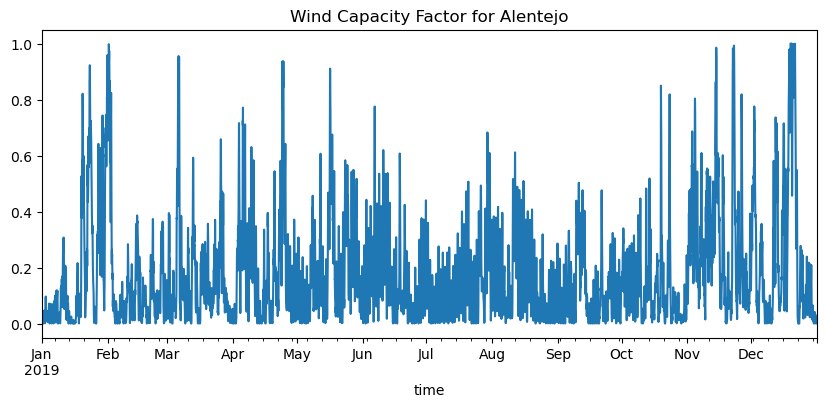

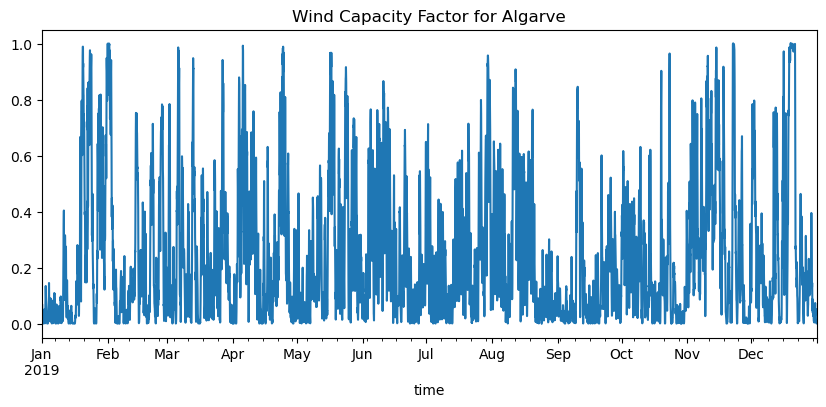

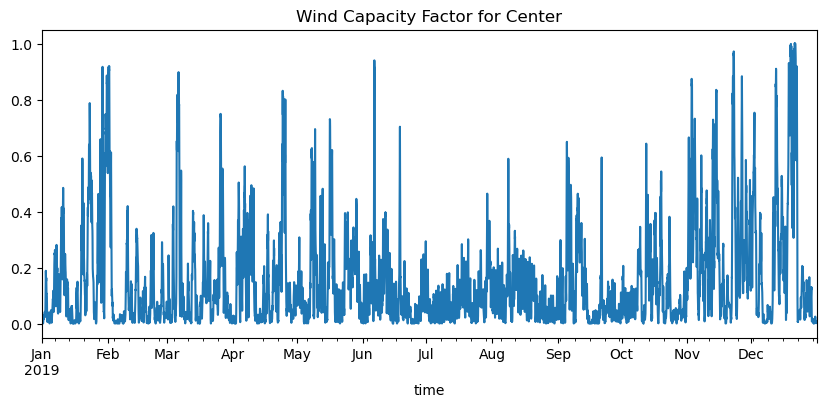

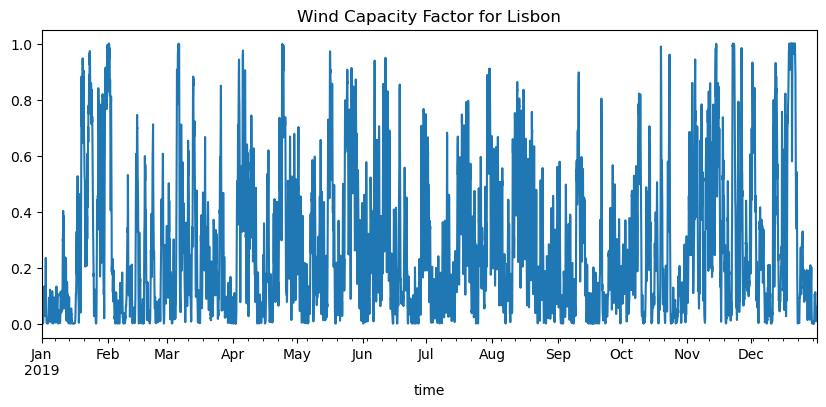

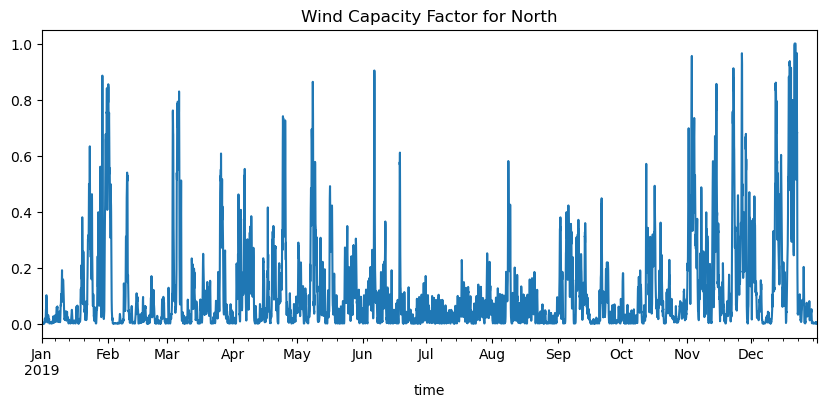

In [39]:
for region in prt_regions["region"]:
    wind_cf_df[region].plot(figsize = (10, 4), title = f"Wind Capacity Factor for {region}")
    plt.show()

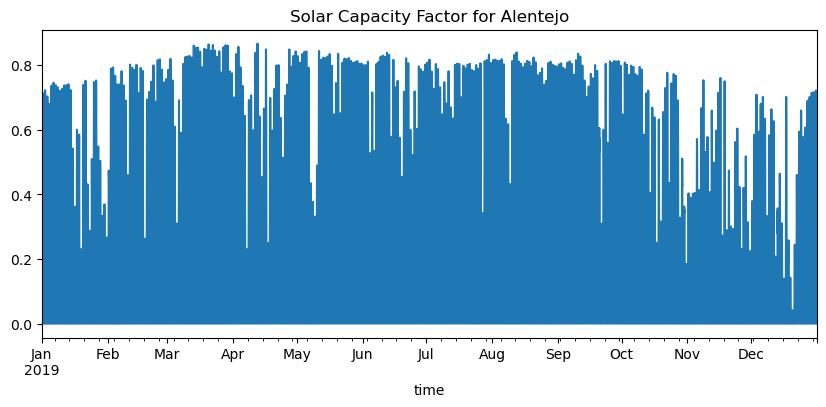

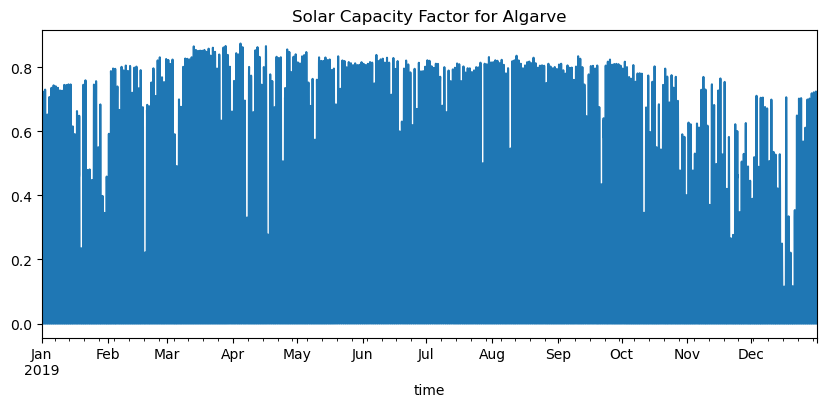

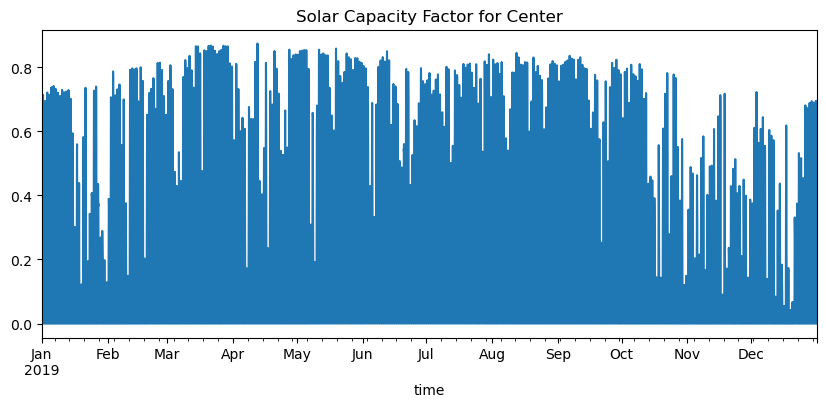

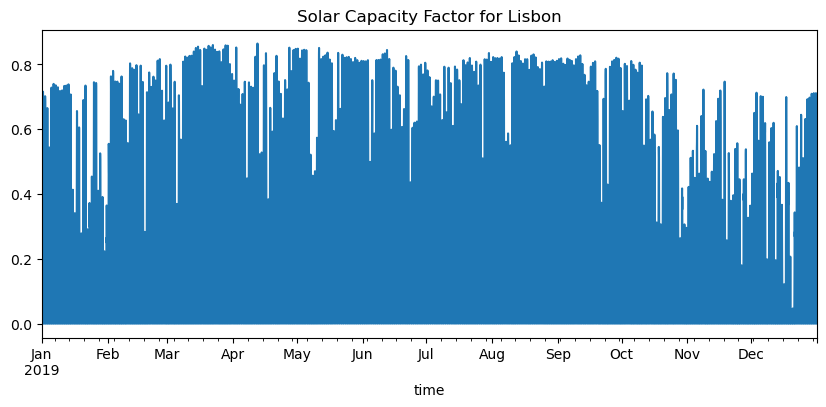

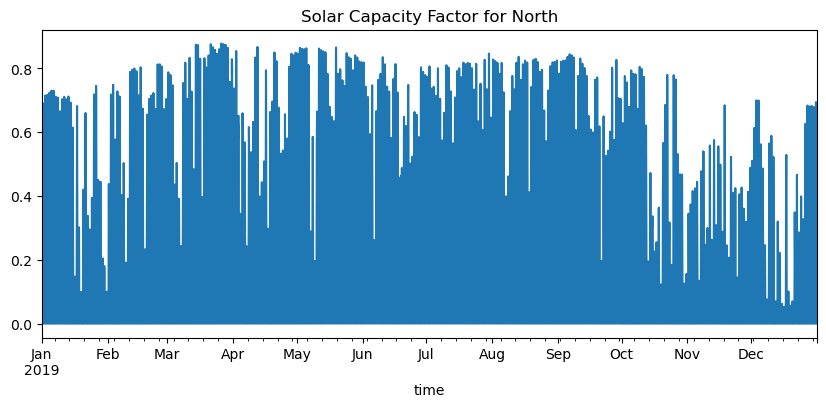

In [40]:
for region in prt_regions["region"]:
    solar_cf_df[region].plot(figsize = (10, 4), title = f"Solar Capacity Factor for {region}")
    plt.show()

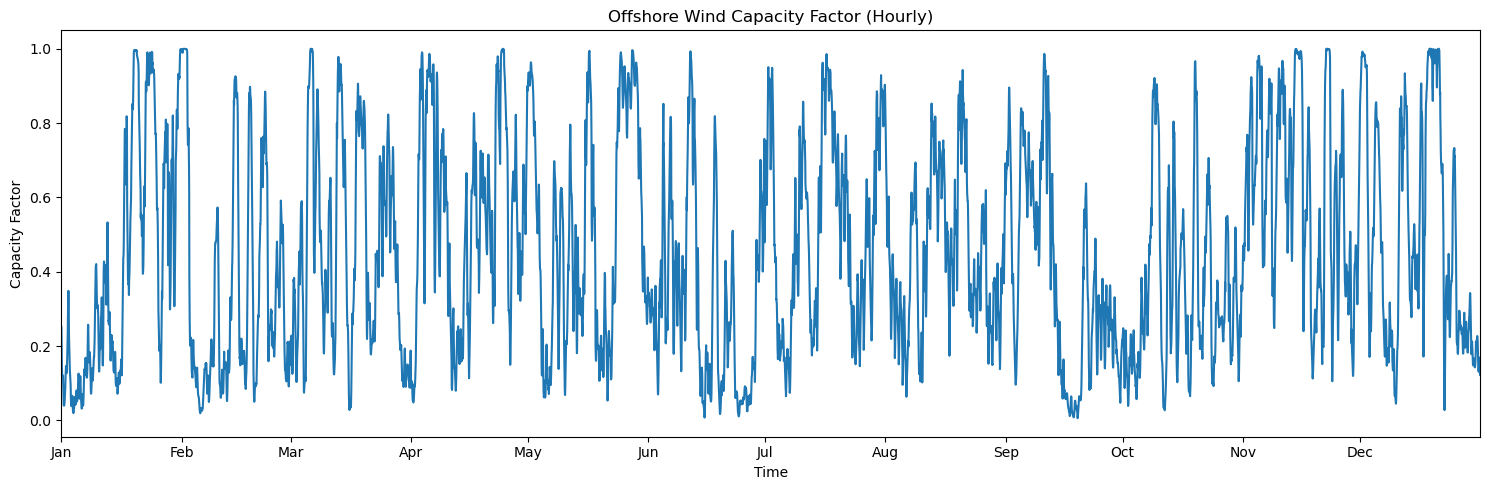

In [41]:
plt.figure(figsize=(15,5))
plt.plot(off_shore_cf_df.index,off_shore_cf_df.iloc[:,0])
plt.title("Offshore Wind Capacity Factor (Hourly)")
plt.xlabel("Time")
plt.ylabel("Capacity Factor")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.margins(x=0)
plt.show()


## Estimation of Maximum Installable Renewable Capacity

The maximum installable capacity for onshore wind, offshore wind, and solar PV is estimated by multiplying the eligible area by an assumed installation density.

### Assumptions

- **Onshore Wind:** 3 MW/km²
- **Offshore Wind:** 5 MW/km² *(or whatever value you are using)*
- **Solar PV:** 3 MW/km² *(or your chosen value)*

The resulting value represents the theoretical maximum installed capacity that can be deployed within the eligible area for each technology.

In [42]:
# Onshore wind
wind_regions["p_nom_max_wind_MW"] = wind_regions["eligible_area_km2"] * 3
display(wind_regions)

,region,area_km2,eligible_pct,eligible_area_km2,p_nom_max_wind_MW
0,Alentejo,30456.291100,24.873350,7575.50,22726.50
1,Algarve,4965.662778,19.465075,966.57,2899.71
2,Center,27396.664669,16.546613,4533.22,13599.66
3,Lisbon,7782.120702,8.442429,657.00,1971.00
4,North,18155.599236,12.713709,2308.25,6924.75


In [43]:
# Solar
solar_regions["p_nom_max_solar_MW"] = solar_regions["eligible_area_km2"] * 3
display(solar_regions)

,region,area_km2,eligible_pct,eligible_area_km2,p_nom_max_solar_MW
0,Alentejo,30456.291100,36.759236,11195.50,33586.50
1,Algarve,4965.662778,34.165228,1696.53,5089.59
2,Center,27396.664669,32.151249,8808.37,26425.11
3,Lisbon,7782.120702,25.706232,2000.49,6001.47
4,North,18155.599236,26.538865,4818.29,14454.87


In [44]:
# Create Offshore Wind DataFrame
offshore_regions = pd.DataFrame({"region": ["Portuguese Exclusive Economic Zone"],"eligible_area_km2": [eligible_area_km2]})
offshore_regions["p_nom_max_offshore_MW"] = (offshore_regions["eligible_area_km2"] * 3)
display(offshore_regions)

,region,eligible_area_km2,p_nom_max_offshore_MW
0,Portuguese Exclusive Economic Zone,4818.29,14454.87


## Daily Average Capacity Factor Comparison

To compare the performance of the renewable energy resources, the hourly capacity factor time series were resampled to daily averages. This reduces short-term fluctuations and highlights the seasonal variability of each technology.

The figure below presents the daily average capacity factors for:

- **Onshore Wind** (five Portuguese regions)
- **Solar PV** (five Portuguese regions)
- **Offshore Wind** (Portuguese Exclusive Economic Zone)

The capacity factor is defined as the ratio of the actual electricity generated to the maximum possible generation if the plant operated at its rated capacity continuously. It is expressed as a value between **0** and **1**, where higher values indicate better utilization of the installed capacity.

These plots provide a visual comparison of the temporal variation in renewable energy availability across different regions and technologies throughout the year.

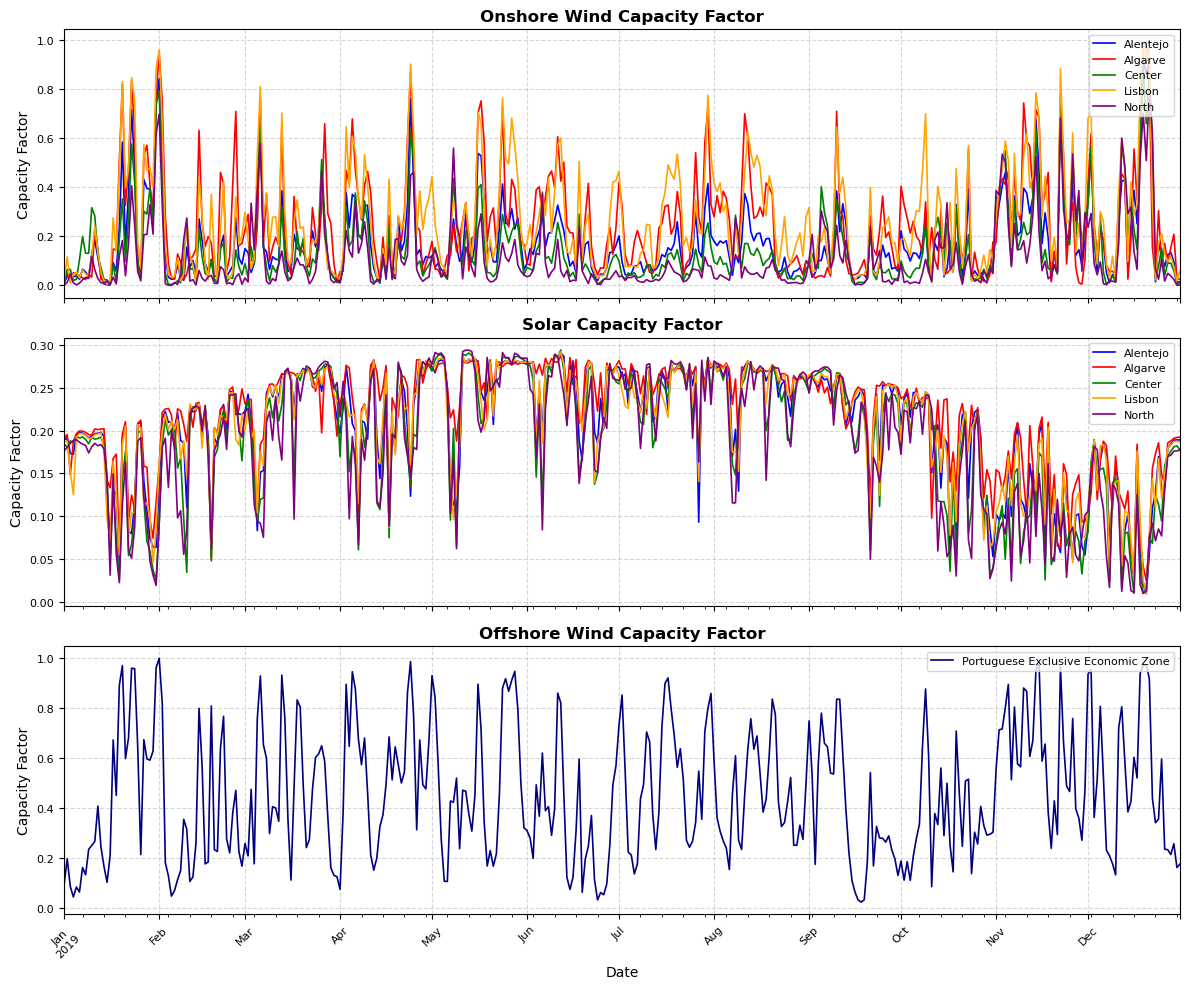

In [45]:
region_colors = ["blue", "red", "green", "orange", "purple"]
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
# Dictionary containing all datasets
datasets = {
    "Onshore Wind": (wind_cf_df, axes[0], region_colors),
    "Solar": (solar_cf_df, axes[1], region_colors),
    "Offshore Wind": (off_shore_cf_df, axes[2], ["navy"])
}
for title, (df, ax, colors) in datasets.items():
    daily_cf = df.resample("D").mean()
    daily_cf.plot(ax=ax,linewidth=1.2,color=colors)
    ax.set_title(f"{title} Capacity Factor",fontsize=12,fontweight="bold")
    ax.set_ylabel("Capacity Factor", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", fontsize=8)
    ax.tick_params(axis="both", labelsize=8)
axes[-1].set_xlabel("Date", fontsize=10)
plt.xticks(rotation=45)
plt.subplots_adjust(hspace=0.35)
plt.tight_layout()
plt.show()

## PYPSA

## Global Powerplants

In [46]:
powerplant = pd.read_csv(gppd_url)
display(powerplant)


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.3220,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.6700,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.6230,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.5560,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.6410,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34931,ZMB,Zambia,Ndola,WRI1022386,50.0,-12.9667,28.6333,Oil,NaN,NaN,...,NaN,NaN,NaN,NaN,183.79,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
34932,ZMB,Zambia,Nkana,WRI1022384,20.0,-12.8167,28.2000,Oil,NaN,NaN,...,NaN,NaN,NaN,NaN,73.51,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
34933,ZMB,Zambia,Victoria Falls,WRI1022380,108.0,-17.9167,25.8500,Hydro,NaN,NaN,...,575.78,575.78,548.94,579.90,578.32,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
34934,ZWE,Zimbabwe,Hwange Coal Power Plant Zimbabwe,GEODB0040404,920.0,-18.3835,26.4700,Coal,NaN,NaN,...,NaN,NaN,NaN,NaN,2785.10,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1


## Powerplant in portugal regionwise 

In [47]:
pt_powerplant = powerplant[powerplant["country_long"] == "Portugal"].reset_index(drop=True)
pt_powerplant = pt_powerplant.iloc[:, 0:9]
geometry_powerplant = [Point(lon, lat) for lon, lat in zip(pt_powerplant["longitude"], pt_powerplant["latitude"])]
powerplant_gdf = gpd.GeoDataFrame(pt_powerplant, geometry=geometry_powerplant, crs="EPSG:4326")
regions = regions.to_crs("EPSG:4326")
powerplant_gdf = gpd.sjoin(powerplant_gdf, regions, how="inner", predicate="within")
powerplant_gdf = powerplant_gdf[["name","capacity_mw","primary_fuel","geometry","region"]]
powerplant_gdf

,name,capacity_mw,primary_fuel,geometry,region
0,Abogalheira,3.34,Wind,POINT (-8.0427 41.1926),North
1,About the Future,2.20,Solar,POINT (-8.8113 38.4916),Lisbon
2,Abrunheira (Ecoparque),2.80,Waste,POINT (-9.2859 38.937),Lisbon
3,Achada,6.90,Wind,POINT (-9.1932 39.1089),Lisbon
4,Acil 1,2.00,Solar,POINT (-8.625 38.7086),Lisbon
...,...,...,...,...,...
463,Vila do Bispo II,10.50,Wind,POINT (-8.8723 37.0964),Algarve
464,Vilar-Tabuaço,58.00,Hydro,POINT (-7.5358 40.9869),Center
465,Vilarchão,2.00,Wind,POINT (-8.0548 41.6443),North
466,Viso,1.20,Wind,POINT (-8.0674 41.4083),North


## Number of Powerplant per regions

In [48]:
# Count the number of power plants in each region
powerplant_count = (
    powerplant_gdf.groupby("region")
    .size()
    .reset_index(name="Number_of_Power_Plants")
)

print(powerplant_count)

     region  Number_of_Power_Plants
0  Alentejo                      53
1   Algarve                      26
2    Center                     165
3    Lisbon                      74
4     North                     116


In [49]:
#Imports and Network Initialization
import pypsa

n = pypsa.Network()

# 3-hourly snapshots
n.snapshots = wind_cf_df.index[::3]

Number of buses: 5


,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
name,,,,,,,,,,,,,
0,1.0,,-7.960804,38.578106,AC,,,1.0,0.0,inf,PQ,,
1,1.0,,-8.149914,37.255175,AC,,,1.0,0.0,inf,PQ,,
2,1.0,,-7.955554,40.213268,AC,,,1.0,0.0,inf,PQ,,
3,1.0,,-8.461003,38.297461,AC,,,1.0,0.0,inf,PQ,,
4,1.0,,-7.496424,41.577520,AC,,,1.0,0.0,inf,PQ,,


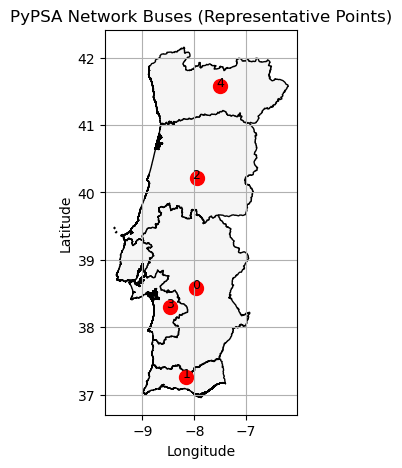

          x          y
0 -7.960804  38.578106
1 -8.149914  37.255175
2 -7.955554  40.213268
3 -8.461003  38.297461
4 -7.496424  41.577520


In [50]:
prt_regions["Representative_Point"] = prt_regions.geometry.representative_point()

# Extract longitude and latitude
prt_regions["x"] = prt_regions["Representative_Point"].x
prt_regions["y"] = prt_regions["Representative_Point"].y
n = pypsa.Network()
for region in prt_regions.index:
    n.add("Bus",name=region,x=prt_regions.loc[region, "x"],
                y=prt_regions.loc[region, "y"])

print("Number of buses:", len(n.buses))
display(n.buses)

fig, ax = plt.subplots(figsize=(5,5))
prt_regions.plot(ax=ax,color="whitesmoke",edgecolor="black")
ax.scatter(prt_regions["x"],prt_regions["y"],color="red",s=100,label="Bus")
for region in prt_regions.index:
    ax.text(prt_regions.loc[region, "x"],prt_regions.loc[region, "y"],region,fontsize=9,ha="center")
plt.title("PyPSA Network Buses (Representative Points)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()
bus_coordinates = prt_regions[["x","y"]].copy()
print(bus_coordinates)

## 10. Existing Power Plants

**Goal:** Complete this stage before moving to the next.

In [51]:
# Count existing power plants in Portugal by model region and fuel type

plants = powerplant_gdf.copy()

# remove rows without capacity
plants = plants.dropna(subset=["capacity_mw"])

# total number of plants per region
plants_per_region = plants.groupby("region").size()

print("Number of power plants per region:")
display(plants_per_region)

Number of power plants per region:


region
Alentejo     53
Algarve      26
Center      165
Lisbon       74
North       116
dtype: int64

In [52]:
# number of power plants per region and primary fuel

plants_per_region_fuel = (
    plants
    .groupby(["region", "primary_fuel"])
    .size()
    .unstack(fill_value=0)
)

print("Number of power plants per region and fuel:")
display(plants_per_region_fuel)

Number of power plants per region and fuel:


primary_fuel,Biomass,Coal,Gas,Hydro,Solar,Waste,Wind
region,,,,,,,
Alentejo,2,1,1,13,28,1,7
Algarve,0,0,0,0,13,2,11
Center,14,0,1,45,4,6,95
Lisbon,2,1,1,2,22,7,39
North,1,0,1,52,1,6,55


In [53]:
# Existing fleet used in the model

CONVENTIONAL_FUELS = ["Gas", "Coal", "Oil", "Biomass", "Waste"]

model_plants = plants[
    plants["primary_fuel"].isin(CONVENTIONAL_FUELS + ["Hydro"])
].copy()

model_plant_count = (
    model_plants
    .groupby(["region", "primary_fuel"])
    .size()
    .unstack(fill_value=0)
)

print("Number of existing modelled power plants:")
display(model_plant_count)

Number of existing modelled power plants:


primary_fuel,Biomass,Coal,Gas,Hydro,Waste
region,,,,,
Alentejo,2,1,1,13,1
Algarve,0,0,0,0,2
Center,14,0,1,45,6
Lisbon,2,1,1,2,7
North,1,0,1,52,6


In [54]:
# --- Existing power plants: one representative generator per region & technology ---

# conventional fuels we know how to price
# (wind & solar are added later as EXPANDABLE renewables; hydro is handled separately)
CONVENTIONAL_FUELS = ["Gas", "Coal", "Oil", "Biomass", "Waste"]

# drop plants with no capacity value
plants = powerplant_gdf.dropna(subset=["capacity_mw"])

# 1) conventional fleet -> total MW per region & fuel
conv = plants[plants["primary_fuel"].isin(CONVENTIONAL_FUELS)]
conv_capacity = conv.groupby(["region", "primary_fuel"])["capacity_mw"].sum()

# 2) hydro -> kept SEPARATE (modelled with a constant capacity factor)
hydro = plants[plants["primary_fuel"] == "Hydro"]
hydro_capacity = hydro.groupby("region")["capacity_mw"].sum()

HYDRO_CF = 0.30   # hydro is rainfall-limited, cannot run at full power all year

# clean table view (regions x fuels)
print("Conventional capacity [MW]:")
display(conv_capacity.unstack(fill_value=0).round(0))
print("Hydro capacity [MW]:")
print(hydro_capacity.round(0))

Conventional capacity [MW]:


primary_fuel,Biomass,Coal,Gas,Waste
region,,,,
Alentejo,23.0,682.0,837.0,1.0
Algarve,0.0,0.0,0.0,3.0
Center,325.0,0.0,826.0,15.0
Lisbon,66.0,1296.0,1176.0,62.0
North,39.0,0.0,990.0,40.0


Hydro capacity [MW]:
region
Alentejo     157.0
Center       536.0
Lisbon         3.0
North       2011.0
Name: capacity_mw, dtype: float64


## 11. Load Distribution

**Goal:** Complete this stage before moving to the next.

In [55]:
# 1) align the demand year (2013) with the weather year (2019) - values unchanged
national_load = national_load.copy()
national_load.index = wind_cf_df.index

# 2) split national demand to regions by population share
# approximate population per region (2021 census, INE Portugal)
population = pd.Series({
    "North":    3_582_000,
    "Center":   2_227_000,
    "Lisbon":   2_871_000,
    "Alentejo":   705_000,
    "Algarve":    467_000,
})
population_share = population / population.sum()

# regional demand = national demand x population share [MW]
regional_load = pd.DataFrame({r: national_load * population_share[r] for r in population.index})
regional_load.head()

,North,Center,Lisbon,Alentejo,Algarve
time,,,,,
2019-01-01 00:00:00,2255.426845,1402.243323,1807.741617,443.907294,294.049229
2019-01-01 01:00:00,2087.646338,1297.930875,1673.264276,410.885167,272.174997
2019-01-01 02:00:00,2006.556120,1247.515489,1608.269855,394.925200,261.602934
2019-01-01 03:00:00,1983.998046,1233.490689,1590.189389,390.485378,258.661945
2019-01-01 04:00:00,1983.998046,1233.490689,1590.189389,390.485378,258.661945


In [68]:
from pypsa.costs import annuity

# --- load technology-data cost assumptions ---
YEAR = 2040
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{YEAR}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

# convert EUR/kW -> EUR/MW (PyPSA base unit)
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {"FOM": 0, "VOM": 0, "efficiency": 1, "fuel": 0, "investment": 0,
            "lifetime": 25, "CO2 intensity": 0, "discount rate": 0.07}
costs = costs.value.unstack().fillna(defaults)

# gas turbines inherit the gas fuel price and CO2 intensity
for tech in ["OCGT", "CCGT"]:
    costs.at[tech, "fuel"] = costs.at["gas", "fuel"]
    costs.at[tech, "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

# --- derived costs ---
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]
annuity_factor = annuity(costs["discount rate"], costs["lifetime"])
costs["capital_cost"] = (annuity_factor + costs["FOM"] / 100) * costs["investment"]

# --- check that every technology our model needs is present ---
needed = ["onwind", "solar", "CCGT", "coal", "oil", "biomass",
          "battery inverter", "battery storage",
          "electrolysis", "fuel cell", "hydrogen storage underground"]
missing = [t for t in needed if t not in costs.index]
print("Missing technologies:", missing)   # should be []  (empty = all present)

# show the ones we use (now including lifetime)
costs.loc[needed, ["marginal_cost", "capital_cost", "efficiency",
                   "lifetime", "CO2 intensity"]].round(2)

Missing technologies: []


parameter,marginal_cost,capital_cost,efficiency,lifetime,CO2 intensity
technology,,,,,
onwind,1.66,120717.11,1.00,30.0,0.00
solar,0.01,54021.19,1.00,40.0,0.00
CCGT,48.84,129353.11,0.59,25.0,0.20
coal,24.35,423983.33,0.36,40.0,0.34
oil,128.72,49965.17,0.35,25.0,0.26
biomass,19.98,371372.75,0.47,30.0,0.00
battery inverter,0.00,19758.59,0.96,10.0,0.00
battery storage,0.00,10128.32,1.00,30.0,0.00
electrolysis,0.00,189823.10,0.65,25.0,0.00


In [70]:
REGION_NAMES = list(regional_load.columns)

# per-region installable potential [MW], indexed by region name
p_nom_max_wind  = wind_regions.set_index("region")["p_nom_max_wind_MW"]
p_nom_max_solar = solar_regions.set_index("region")["p_nom_max_solar_MW"]

# representative points (bus coordinates); regions indexed by name, in EPSG:4326
pts = regions.geometry.representative_point()
coords = {r: (pts[r].x, pts[r].y) for r in REGION_NAMES}

# neighbours: regions that share a border
neighbours = []
for a in REGION_NAMES:
    for b in REGION_NAMES:
        if a < b and regions.geometry[a].touches(regions.geometry[b]):
            neighbours.append((a, b))

# crow-fly distances [km]
pts_m = pts.to_crs("EPSG:4087")
distances = pd.DataFrame({a: pts_m.distance(p) for a, p in pts_m.items()}).div(1e3)
distances.index = pts.index

# --- show all the results ---
print("Regions:", REGION_NAMES)
print("\nNeighbours (transmission links):", neighbours)

print("\nMax installable potential per region [MW]:")
display(pd.DataFrame({"wind": p_nom_max_wind, "solar": p_nom_max_solar}).round(0))

print("Crow-fly distances between regions [km]:")
display(distances.round(0))

Regions: ['North', 'Center', 'Lisbon', 'Alentejo', 'Algarve']

Neighbours (transmission links): [('Center', 'North'), ('Center', 'Lisbon'), ('Alentejo', 'Center'), ('Alentejo', 'Lisbon'), ('Alentejo', 'Algarve')]

Max installable potential per region [MW]:


,wind,solar
region,,
Alentejo,22726.0,33586.0
Algarve,2900.0,5090.0
Center,13600.0,26425.0
Lisbon,1971.0,6001.0
North,6925.0,14455.0


Crow-fly distances between regions [km]:


,Alentejo,Algarve,Center,Lisbon,North
region,,,,,
Alentejo,0.0,149.0,182.0,64.0,338.0
Algarve,149.0,0.0,330.0,121.0,487.0
Center,182.0,330.0,0.0,221.0,160.0
Lisbon,64.0,121.0,221.0,0.0,381.0
North,338.0,487.0,160.0,381.0,0.0


## 12. Build PyPSA Network

**Goal:** Complete this stage before moving to the next.

In [63]:
import pypsa

network = pypsa.Network()

# use 3-hourly snapshots
snapshots = wind_cf_df.index[::3]
network.set_snapshots(snapshots)

# each snapshot represents 3 hours
network.snapshot_weightings["objective"] = 3


# -------------------------
# Add buses
# -------------------------

bus_regions = list(regional_load.columns)

bus_shapes = regions.to_crs(4326).copy()
bus_shapes["point"] = bus_shapes.geometry.representative_point()
bus_shapes["x"] = bus_shapes["point"].x
bus_shapes["y"] = bus_shapes["point"].y

for region in bus_regions:
    network.add(
        "Bus",
        region,
        x=bus_shapes.loc[region, "x"],
        y=bus_shapes.loc[region, "y"],
    )

print("Buses added:", len(network.buses))


# -------------------------
# Add loads
# -------------------------

for region in bus_regions:
    network.add(
        "Load",
        f"load_{region}",
        bus=region,
        p_set=regional_load.loc[snapshots, region],
    )

print("Loads added:", len(network.loads))


# -------------------------
# Add renewable generators
# -------------------------

wind_max = wind_regions.set_index("region")["p_nom_max_wind_MW"]
solar_max = solar_regions.set_index("region")["p_nom_max_solar_MW"]

for region in bus_regions:
    network.add(
        "Generator",
        f"onwind_{region}",
        bus=region,
        carrier="onwind",
        p_nom_extendable=True,
        p_nom_min=0,
        p_nom_max=wind_max.loc[region],
        p_max_pu=wind_cf_df.loc[snapshots, region],
        capital_cost=0,      # updated in technology-cost section
        marginal_cost=0,
    )

    network.add(
        "Generator",
        f"solar_{region}",
        bus=region,
        carrier="solar",
        p_nom_extendable=True,
        p_nom_min=0,
        p_nom_max=solar_max.loc[region],
        p_max_pu=solar_cf_df.loc[snapshots, region],
        capital_cost=0,      # updated in technology-cost section
        marginal_cost=0,
    )

print("Renewable generators added")


# -------------------------
# Add existing conventional generators
# -------------------------

if isinstance(conv_capacity, pd.Series):
    conv_table = conv_capacity.unstack(fill_value=0)
else:
    conv_table = conv_capacity.copy()

for region in conv_table.index:
    for fuel in conv_table.columns:
        capacity = conv_table.loc[region, fuel]

        if capacity > 0:
            network.add(
                "Generator",
                f"{fuel}_{region}_existing",
                bus=region,
                carrier=fuel,
                p_nom=capacity,
                p_nom_extendable=False,
                capital_cost=0,
                marginal_cost=0,   # updated in technology-cost section
            )

print("Existing conventional generators added")


# -------------------------
# Add existing hydro
# -------------------------

for region, capacity in hydro_capacity.items():
    if capacity > 0:
        network.add(
            "Generator",
            f"hydro_{region}_existing",
            bus=region,
            carrier="hydro",
            p_nom=capacity,
            p_nom_extendable=False,
            p_max_pu=HYDRO_CF,
            capital_cost=0,
            marginal_cost=0,
        )

print("Hydro generators added")


# -------------------------
# Add storage
# -------------------------

battery_hours = [2, 4, 6]
hydrogen_hours = [168, 336, 672]

for region in bus_regions:
    for hours in battery_hours:
        network.add(
            "StorageUnit",
            f"battery_{hours}h_{region}",
            bus=region,
            carrier="battery",
            p_nom_extendable=True,
            max_hours=hours,
            efficiency_store=0.90,
            efficiency_dispatch=0.90,
            capital_cost=0,      # updated in technology-cost section
            marginal_cost=0,
        )

    for hours in hydrogen_hours:
        network.add(
            "StorageUnit",
            f"hydrogen_{hours}h_{region}",
            bus=region,
            carrier="hydrogen",
            p_nom_extendable=True,
            max_hours=hours,
            efficiency_store=0.70,
            efficiency_dispatch=0.50,
            capital_cost=0,      # updated in technology-cost section
            marginal_cost=0,
        )

print("Storage units added:", len(network.storage_units))


# -------------------------
# Add transmission links
# -------------------------

neighbours = [
    ("North", "Center"),
    ("Center", "Lisbon"),
    ("Center", "Alentejo"),
    ("Lisbon", "Alentejo"),
    ("Alentejo", "Algarve"),
]

region_points = regions.to_crs(3035).copy()
region_points["point"] = region_points.geometry.representative_point()

link_cost_per_MW_km = 700

for bus0, bus1 in neighbours:
    distance_km = region_points.loc[bus0, "point"].distance(
        region_points.loc[bus1, "point"]
    ) / 1000

    link_length_km = 1.5 * distance_km

    network.add(
        "Link",
        f"{bus0}-{bus1}",
        bus0=bus0,
        bus1=bus1,
        carrier="transmission",
        p_nom_extendable=True,
        p_min_pu=-1,
        p_max_pu=1,
        length=link_length_km,
        capital_cost=link_cost_per_MW_km * link_length_km,
        efficiency=1.0,
    )

print("Transmission links added:", len(network.links))


# -------------------------
# Check network
# -------------------------

print(network)

Buses added: 5
Loads added: 5
Renewable generators added
Existing conventional generators added
Hydro generators added
Storage units added: 30
Transmission links added: 5
PyPSA Network 'Unnamed Network'


## 13. Technology Costs

**Goal:** Complete this stage before moving to the next.

In [57]:
# TODO
# Read PyPSA technology-data
# Compute annuities (7% discount rate)
# Capital cost
# Marginal cost

## 14. Scenario 1

**Goal:** Complete this stage before moving to the next.

In [58]:
# TODO
# Run without CO2 constraint
# network.optimize()

## 15. Scenario 2

**Goal:** Complete this stage before moving to the next.

In [59]:
# TODO
# Run with 100% CO2 reduction

## 16. Sensitivity Analysis

**Goal:** Complete this stage before moving to the next.

In [60]:
# TODO
# Grid expansion
# Technology costs
# Renewable potential
# Weather year
# Nuclear cost

## 17. Visualizations

**Goal:** Complete this stage before moving to the next.

In [61]:
# TODO
# Electricity mix
# Installed capacities
# Storage
# Transmission
# Curtailment
# System cost
# CO2 emissions

## 18. Conclusions

**Goal:** Complete this stage before moving to the next.

In [62]:
# Summarize findings
# Compare scenarios
# Prepare presentation figures